In [1]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import mlflow
import joblib
import os

# Connect to workspace
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
print("Connected:", ml_client.workspaces.get("ml-learning-workspace").name)

Found the config file in: /config.json


Connected: ml-learning-workspace


In [2]:
# Load and prepare data
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Split data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

# Train model
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = (model.predict(X_test) == y_test).mean()
print(f"Model accuracy: {accuracy:.4f}")

# Save data and model
os.makedirs("rai_data", exist_ok=True)
os.makedirs("rai_model", exist_ok=True)

train_df.to_csv("rai_data/train.csv", index=False)
test_df.to_csv("rai_data/test.csv", index=False)
joblib.dump(model, "rai_model/model.pkl")
print("Model and data saved")

Model accuracy: 0.9561
Model and data saved


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


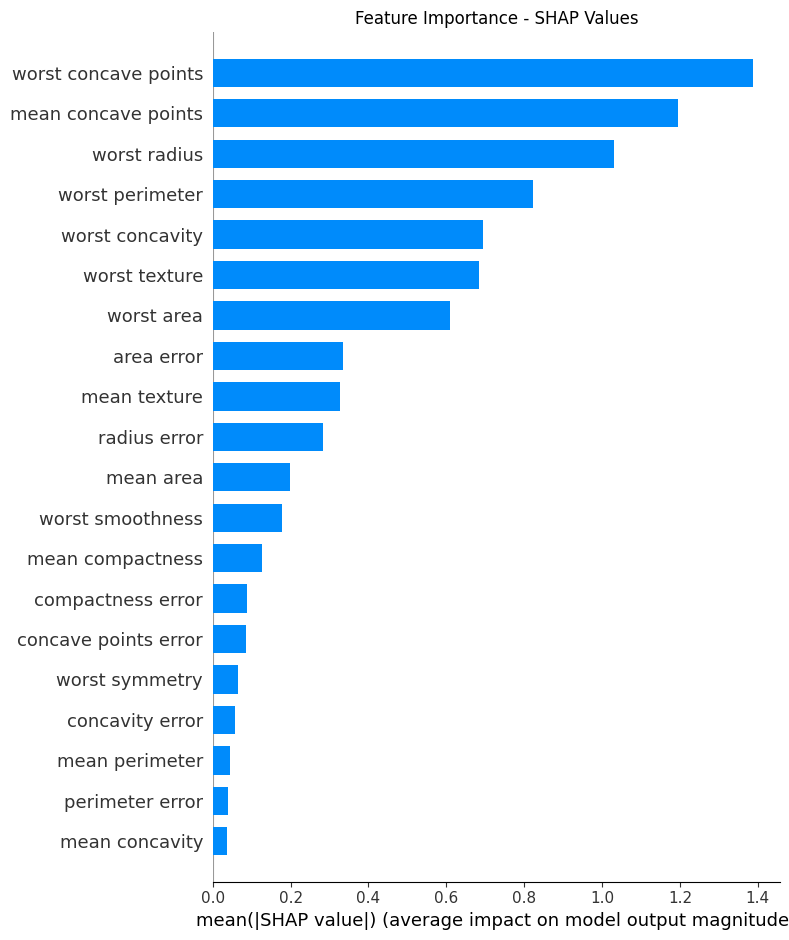

Feature importance plot saved


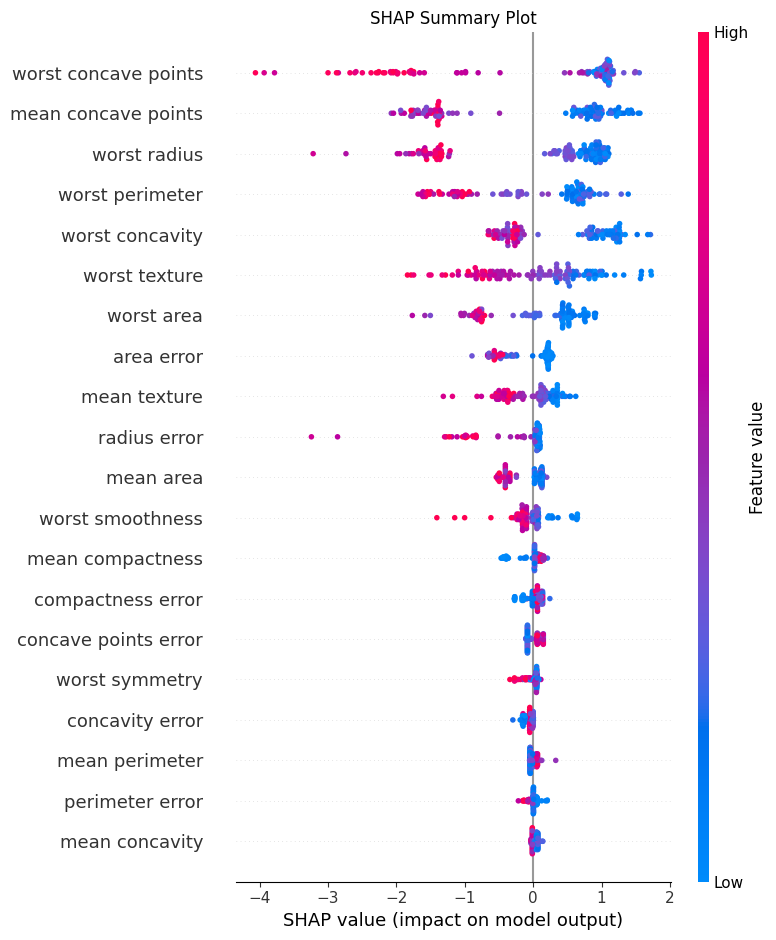

SHAP summary plot saved


In [3]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Feature importance summary
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance - SHAP Values")
plt.tight_layout()
plt.savefig("rai_data/shap_importance.png")
plt.show()
print("Feature importance plot saved")

# Plot 2 - SHAP summary dot plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("rai_data/shap_summary.png")
plt.show()
print("SHAP summary plot saved")

Actual: Benign
Predicted: Benign
Prediction probability: [8.62720920e-04 9.99137279e-01]


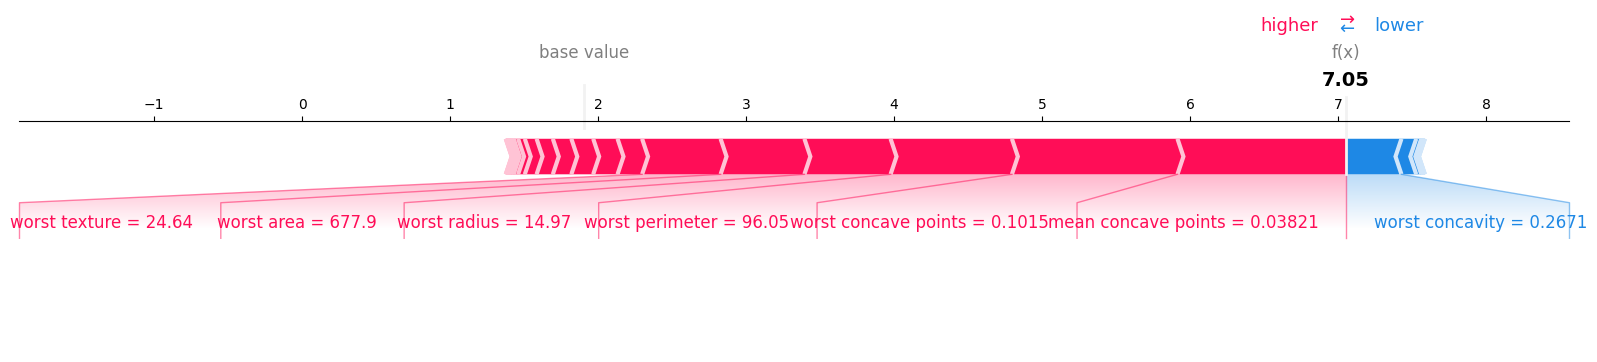

Single prediction explanation saved


In [4]:
# Explain a single prediction
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]
actual = y_test.iloc[sample_idx]
predicted = model.predict(sample)[0]

print(f"Actual: {'Benign' if actual == 1 else 'Malignant'}")
print(f"Predicted: {'Benign' if predicted == 1 else 'Malignant'}")
print(f"Prediction probability: {model.predict_proba(sample)[0]}")

# Force plot for single prediction
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.savefig("rai_data/shap_single_prediction.png", bbox_inches='tight')
plt.show()
print("Single prediction explanation saved")

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        43
      Benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



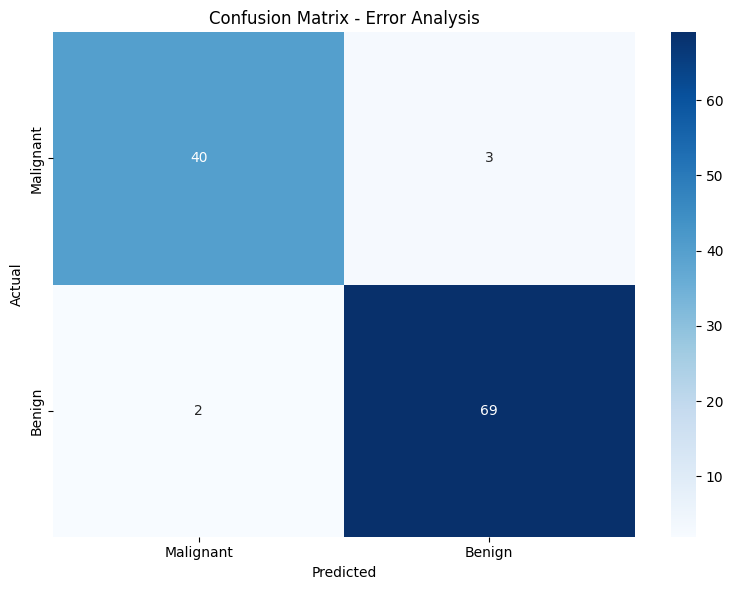


Total misclassified: 5 out of 114
False positives (predicted benign, actually malignant): 3
False negatives (predicted malignant, actually benign): 2


In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Error Analysis')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("rai_data/confusion_matrix.png")
plt.show()

# Find misclassified samples
misclassified = X_test[y_pred != y_test].copy()
misclassified['actual'] = y_test[y_pred != y_test]
misclassified['predicted'] = y_pred[y_pred != y_test]
print(f"\nTotal misclassified: {len(misclassified)} out of {len(y_test)}")
print(f"False positives (predicted benign, actually malignant): {((y_pred == 1) & (y_test == 0)).sum()}")
print(f"False negatives (predicted malignant, actually benign): {((y_pred == 0) & (y_test == 1)).sum()}")